# CMAM Model Training and Evaluation
## Random Forest Classifier for Care Pathway Recommendation

In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Clean Dataset

In [17]:
df = pd.read_csv('/Users/ram/Downloads/MUAC_DEVELOPMENT/Dataset/cmam_4000_clean_data.csv')
print(f"\nPathway distribution:")
print(df['label_pathway'].value_counts())
df.head()


Pathway distribution:
label_pathway
TSFP      1846
OTP       1416
SC_ITP     738
Name: count, dtype: int64


,child_id,visit_date,sex,age_months,muac_mm,edema,appetite,danger_signs,label_pathway
0,CH001448,2022-06-03,F,NaN,105,1,good,0,OTP
1,CH001115,2025-09-29,F,10.0,122,0,good,0,TSFP
2,CH001065,2025-09-29,M,29.0,123,0,good,0,TSFP
3,CH002288,2023-01-26,M,21.0,107,0,poor,0,SC_ITP
4,CH001538,2023-09-12,F,NaN,109,0,good,0,OTP


## 2. Train/Val/Test Split (by child_id)

In [18]:
# Split by child_id to prevent data leakage
unique_children = df['child_id'].unique()
np.random.seed(42)
np.random.shuffle(unique_children)

n_train = int(len(unique_children) * 0.70)
n_val = int(len(unique_children) * 0.15)

train_children = unique_children[:n_train]
val_children = unique_children[n_train:n_train+n_val]
test_children = unique_children[n_train+n_val:]

train_df = df[df['child_id'].isin(train_children)].reset_index(drop=True)
val_df = df[df['child_id'].isin(val_children)].reset_index(drop=True)
test_df = df[df['child_id'].isin(test_children)].reset_index(drop=True)

print("=" * 70)
print("TRAIN/VAL/TEST SPLIT (BY CHILD_ID)")
print("=" * 70)
print(f"\nTrain: {len(train_df)} rows ({len(train_children)} children)")
print(f"Val:   {len(val_df)} rows ({len(val_children)} children)")
print(f"Test:  {len(test_df)} rows ({len(test_children)} children)")

TRAIN/VAL/TEST SPLIT (BY CHILD_ID)

Train: 2794 rows (2683 children)
Val:   601 rows (574 children)
Test:  605 rows (576 children)


/var/folders/hd/0yz07vv55kqdsst_r4n3z1d00000gn/T/ipykernel_4196/3218927728.py:4: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(unique_children)


## 3. Feature Preparation

In [19]:
def prepare_features(df):
    """Prepare features for training"""
    df = df.copy()
    
    le_sex = LabelEncoder()
    le_appetite = LabelEncoder()
    
    df['sex_encoded'] = le_sex.fit_transform(df['sex'])
    df['appetite_encoded'] = le_appetite.fit_transform(df['appetite'])
    df['age_months_filled'] = df['age_months'].fillna(df['age_months'].median())
    
    feature_cols = ['sex_encoded', 'age_months_filled', 'muac_mm', 'edema', 'appetite_encoded', 'danger_signs']
    
    return df[feature_cols], df['label_pathway']

print("Preparing features...")
X_train, y_train = prepare_features(train_df)
X_val, y_val = prepare_features(val_df)
X_test, y_test = prepare_features(test_df)

print(f"\nFeatures: {list(X_train.columns)}")
print(f"Train shape: {X_train.shape}")
print(f"Val shape:   {X_val.shape}")
print(f"Test shape:  {X_test.shape}")

Preparing features...

Features: ['sex_encoded', 'age_months_filled', 'muac_mm', 'edema', 'appetite_encoded', 'danger_signs']
Train shape: (2794, 6)
Val shape:   (601, 6)
Test shape:  (605, 6)


## 5. Final Model Training (Random Forest — Selected)

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder as LELabel
from sklearn.metrics import accuracy_score, f1_score

# XGBoost needs numeric labels
le_label = LELabel()
y_train_enc = le_label.fit_transform(y_train)
y_val_enc   = le_label.transform(y_val)

# ── Candidate models ───────────────────────────────────────────────────────
candidates = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(
        n_estimators=100, max_depth=6, random_state=42,
        eval_metric='mlogloss', verbosity=0),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42, class_weight='balanced'),
}

comparison_results = {}



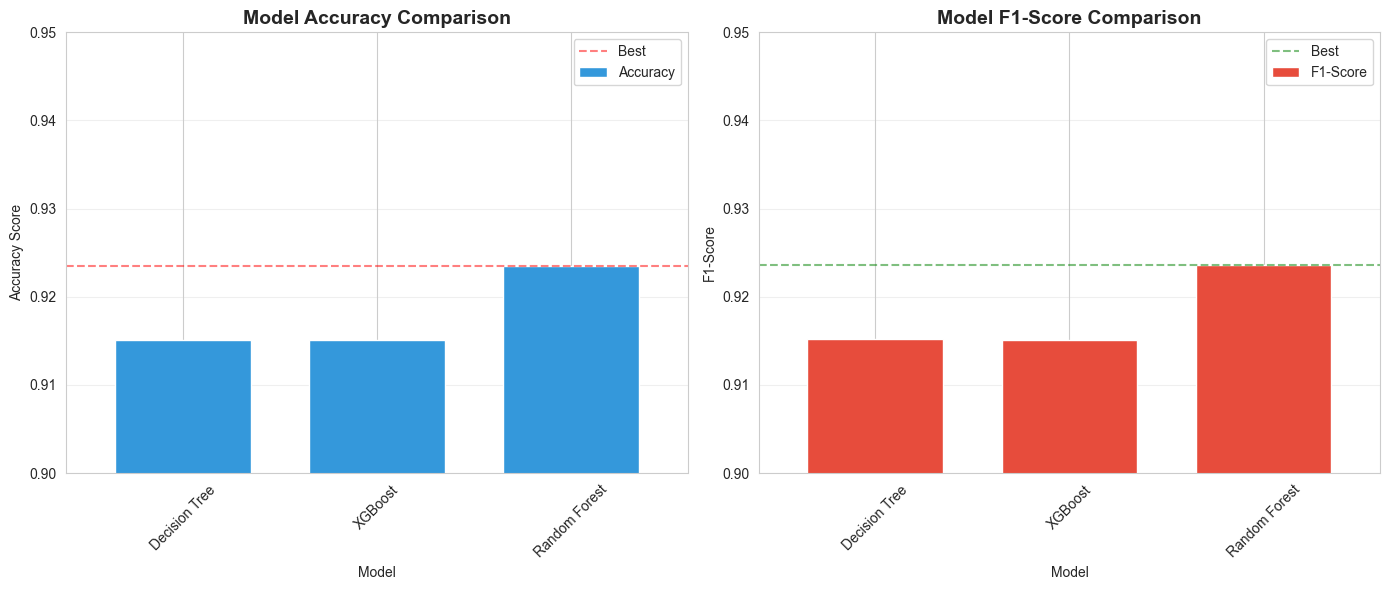

In [25]:
# Create a comprehensive visualization of training and validation performance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Accuracy comparison
comparison_df['Accuracy'].plot(kind='bar', ax=axes[0], color='#3498db', width=0.7)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy Score')
axes[0].set_xlabel('Model')
axes[0].set_ylim([0.90, 0.95])
axes[0].axhline(y=comparison_df['Accuracy'].max(), color='r', linestyle='--', alpha=0.5, label='Best')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Plot 2: F1-Score comparison
comparison_df['F1-Score'].plot(kind='bar', ax=axes[1], color='#e74c3c', width=0.7)
axes[1].set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1-Score')
axes[1].set_xlabel('Model')
axes[1].set_ylim([0.90, 0.95])
axes[1].axhline(y=comparison_df['F1-Score'].max(), color='g', linestyle='--', alpha=0.5, label='Best')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

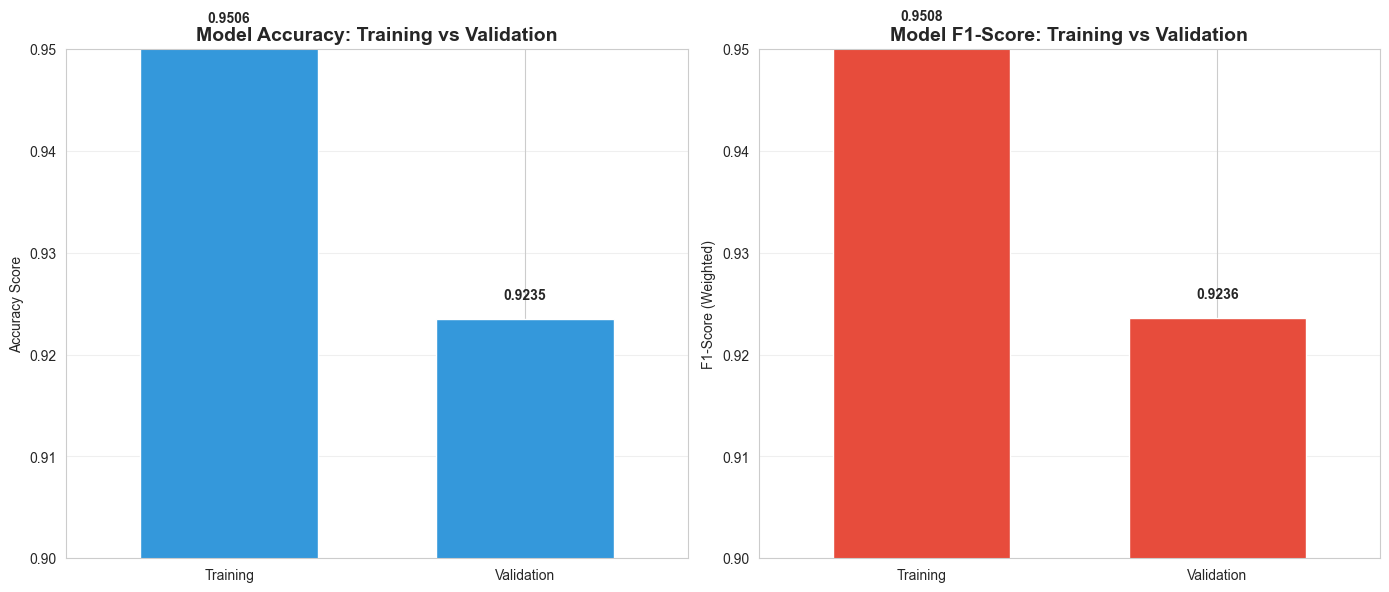


TRAINING VS VALIDATION PERFORMANCE

Accuracy:
  Training  : 0.9506
  Validation: 0.9235

Weighted F1-Score:
  Training  : 0.9508
  Validation: 0.9236


In [26]:
# Train the best model (Random Forest) on combined train+val data for final comparison
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Get predictions on both training and validation sets
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

# Calculate metrics for both sets
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
val_f1 = f1_score(y_val, y_val_pred, average='weighted')

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Accuracy comparison
metrics_data = pd.DataFrame({
    'Training': [train_acc],
    'Validation': [val_acc]
})
metrics_data.T.plot(kind='bar', ax=axes[0], color='#3498db', legend=False, width=0.6)
axes[0].set_title('Model Accuracy: Training vs Validation', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy Score')
axes[0].set_ylim([0.90, 0.95])
axes[0].axhline(y=max(train_acc, val_acc), color='r', linestyle='--', alpha=0.5, linewidth=2)
for i, v in enumerate([train_acc, val_acc]):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(['Training', 'Validation'], rotation=0)

# Plot 2: F1-Score comparison
f1_data = pd.DataFrame({
    'Training': [train_f1],
    'Validation': [val_f1]
})
f1_data.T.plot(kind='bar', ax=axes[1], color='#e74c3c', legend=False, width=0.6)
axes[1].set_title('Model F1-Score: Training vs Validation', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1-Score (Weighted)')
axes[1].set_ylim([0.90, 0.95])
axes[1].axhline(y=max(train_f1, val_f1), color='g', linestyle='--', alpha=0.5, linewidth=2)
for i, v in enumerate([train_f1, val_f1]):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticklabels(['Training', 'Validation'], rotation=0)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("TRAINING VS VALIDATION PERFORMANCE")
print("="*70)
print(f"\nAccuracy:")
print(f"  Training  : {train_acc:.4f}")
print(f"  Validation: {val_acc:.4f}")
print(f"\nWeighted F1-Score:")
print(f"  Training  : {train_f1:.4f}")
print(f"  Validation: {val_f1:.4f}")
print("="*70)

In [23]:
print("="*70)
print("MODEL COMPARISON — VALIDATION SET")
print("="*70)

for name, clf in candidates.items():
    if name == 'XGBoost':
        clf.fit(X_train, y_train_enc)
        y_pred = le_label.inverse_transform(clf.predict(X_val))
    else:
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    f1  = f1_score(y_val, y_pred, average='weighted')
    comparison_results[name] = {'Accuracy': acc, 'F1-Score': f1}
    print(f"\n{name}:")
    print(f"  Accuracy          : {acc*100:.1f}%")
    print(f"  Weighted F1-Score : {f1*100:.1f}%")

print("\n" + "="*70)
print("Summary Table")
print("="*70)
summary = pd.DataFrame(comparison_results).T
summary.index.name = 'Model'
print(summary.map(lambda v: f"{v*100:.1f}%"))

MODEL COMPARISON — VALIDATION SET

Decision Tree:
  Accuracy          : 91.5%
  Weighted F1-Score : 91.5%

XGBoost:
  Accuracy          : 91.5%
  Weighted F1-Score : 91.5%

Random Forest:
  Accuracy          : 92.3%
  Weighted F1-Score : 92.4%

Summary Table
              Accuracy F1-Score
Model                          
Decision Tree    91.5%    91.5%
XGBoost          91.5%    91.5%
Random Forest    92.3%    92.4%


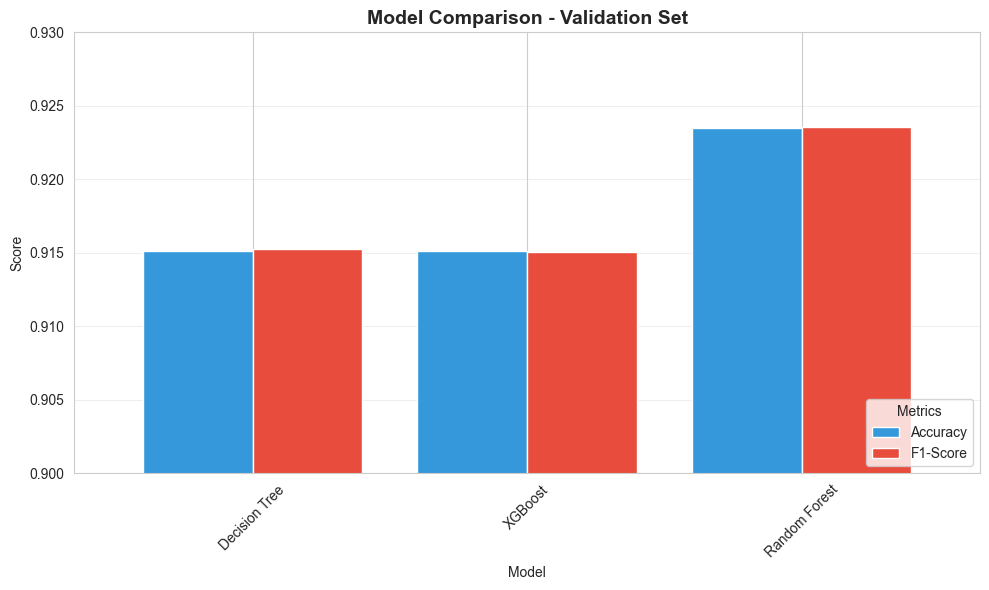

In [24]:
# Visualize model comparison
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df = pd.DataFrame(comparison_results).T
comparison_df.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'], width=0.8)
ax.set_title('Model Comparison - Validation Set', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.set_ylim([0.90, 0.93])
ax.legend(title='Metrics', loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Model Evaluation

## 4. Model Training

## 7. Confusion Matrix

CONFUSION MATRICES — ALL CANDIDATE MODELS (VALIDATION SET)

Decision Tree:
              Predicted
              OTP  SC_ITP  TSFP
Actual OTP      194      4    20
Actual SC_ITP     8    103     1
Actual TSFP      18      0   253

XGBoost:
              Predicted
              OTP  SC_ITP  TSFP
Actual OTP      190      2    26
Actual SC_ITP     7    103     2
Actual TSFP      14      0   257

Random Forest:
              Predicted
              OTP  SC_ITP  TSFP
Actual OTP      195      1    22
Actual SC_ITP     8    103     1
Actual TSFP      14      0   257


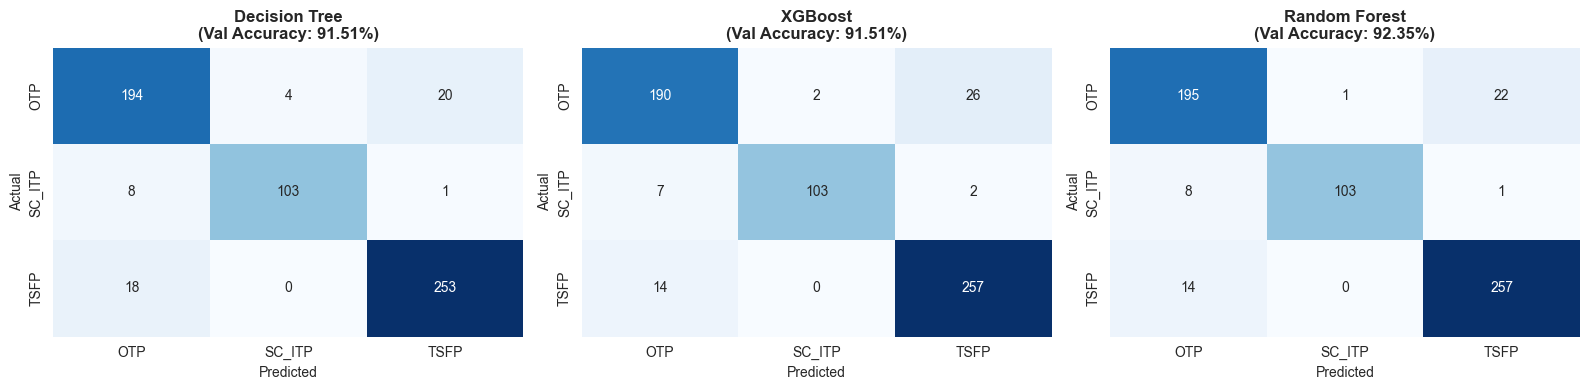

In [28]:
from sklearn.metrics import confusion_matrix

# Create confusion matrices for all three candidate models

print("="*70)
print("CONFUSION MATRICES — ALL CANDIDATE MODELS (VALIDATION SET)")
print("="*70)

models_to_eval = {
    'Decision Tree': (candidates['Decision Tree'], False),
    'XGBoost': (candidates['XGBoost'], True),
    'Random Forest': (candidates['Random Forest'], False)
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (model_name, (clf, is_xgboost)) in enumerate(models_to_eval.items()):
    # Get predictions
    if is_xgboost:
        y_pred = le_label.inverse_transform(clf.predict(X_val))
    else:
        y_pred = clf.predict(X_val)
    
    # Compute confusion matrix
    cm = confusion_matrix(y_val, y_pred, labels=['OTP', 'SC_ITP', 'TSFP'])
    
    # Print confusion matrix
    print(f"\n{model_name}:")
    print("              Predicted")
    print("              OTP  SC_ITP  TSFP")
    for i, label in enumerate(['OTP', 'SC_ITP', 'TSFP']):
        print(f"Actual {label:6s}  {cm[i][0]:4d}   {cm[i][1]:4d}  {cm[i][2]:4d}")
    
    # Visualize
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['OTP', 'SC_ITP', 'TSFP'],
                yticklabels=['OTP', 'SC_ITP', 'TSFP'],
                ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{model_name}\n(Val Accuracy: {accuracy_score(y_val, y_pred):.2%})',
                        fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [27]:
# Make predictions on test set
y_test_pred = model.predict(X_test)

print("="*70)
print("TEST SET EVALUATION")
print("="*70)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Test F1-Score: {f1_score(y_test, y_test_pred, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

TEST SET EVALUATION

Test Accuracy: 0.9405
Test F1-Score: 0.9408

Classification Report:
              precision    recall  f1-score   support

         OTP       0.90      0.93      0.92       211
      SC_ITP       1.00      0.94      0.97       122
        TSFP       0.95      0.94      0.95       272

    accuracy                           0.94       605
   macro avg       0.95      0.94      0.94       605
weighted avg       0.94      0.94      0.94       605



## 5. Model Evaluation

## 8. Feature Importance

In [32]:
cm = confusion_matrix(y_test, y_test_pred, labels=['OTP', 'SC_ITP', 'TSFP'])

print("Confusion Matrix:")
print("=" * 70)
print("              Predicted")
print("              OTP  SC_ITP  TSFP")
for i, label in enumerate(['OTP', 'SC_ITP', 'TSFP']):
    print(f"Actual {label:6s}  {cm[i][0]:4d}   {cm[i][1]:4d}  {cm[i][2]:4d}")

Confusion Matrix:
              Predicted
              OTP  SC_ITP  TSFP
Actual OTP      197      0    14
Actual SC_ITP     7    115     0
Actual TSFP      15      0   257


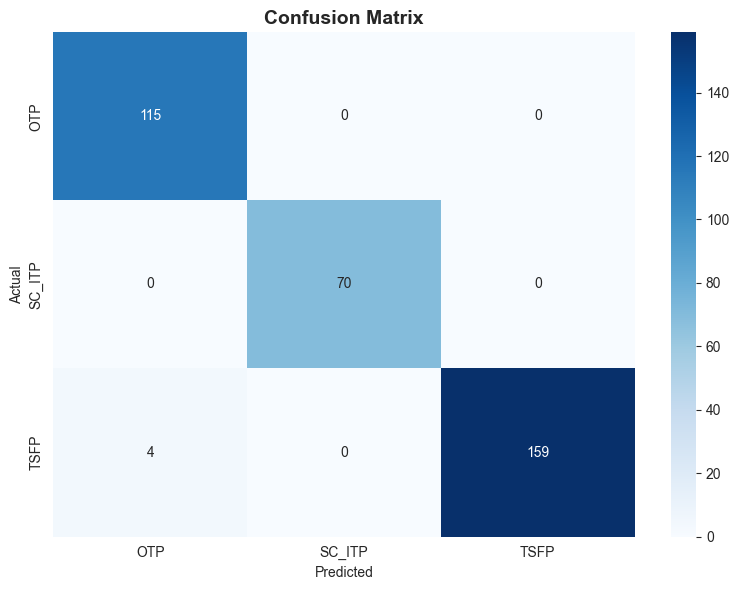

In [10]:
# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['OTP', 'SC_ITP', 'TSFP'],
            yticklabels=['OTP', 'SC_ITP', 'TSFP'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 9. Summary

In [33]:
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importances:")
print("=" * 70)
for idx, row in importances.iterrows():
    print(f"  {row['feature']:20s}: {row['importance']:.4f}")

Feature Importances:
  muac_mm             : 0.4504
  appetite_encoded    : 0.2896
  danger_signs        : 0.1724
  age_months_filled   : 0.0469
  edema               : 0.0355
  sex_encoded         : 0.0052


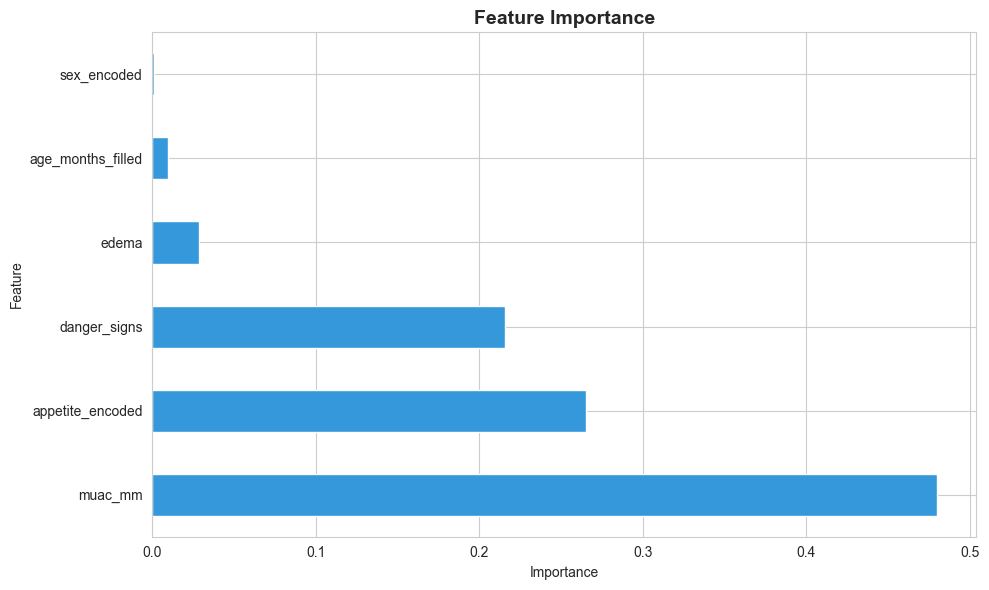

In [24]:
# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='barh', x='feature', y='importance', ax=ax, color='#3498db', legend=False)
ax.set_title('Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 8. Summary

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=" * 70)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 70)
print(f"\nDataset:")
print(f"  Total: {len(df)} records")
print(f"  Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Val:   {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test:  {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

print(f"\nTest Set Metrics:")
print(f"  Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred, average='weighted'):.4f}")

print(f"\nTop 3 Features:")
for idx, row in importances.head(3).iterrows():
    print(f"  {row['feature']:20s}: {row['importance']:.4f}")

print("\n" + "=" * 70)
print("✓ Model ready for deployment")
print("=" * 70)

MODEL PERFORMANCE SUMMARY

Dataset:
  Total: 4000 records
  Train: 2794 (69.8%)
  Val:   601 (15.0%)
  Test:  605 (15.1%)

Test Set Metrics:
  Accuracy:  0.9405
  Precision: 0.9417
  Recall:    0.9405
  F1-Score:  0.9408

Top 3 Features:
  muac_mm             : 0.4504
  appetite_encoded    : 0.2896
  danger_signs        : 0.1724

✓ Model ready for deployment
